# Pricing Options: From Black–Scholes to Monte Carlo
## Step 2 — The assumptions of the Black–Scholes model

**Target audience:** second-year undergraduate students  
**Goal of this notebook:** understand the assumptions behind the Black–Scholes model, why they are useful, and why they are not perfectly realistic.

---

## Learning objectives

At the end of this notebook, the student should be able to:

- state the main assumptions of the Black–Scholes model,
- explain why these assumptions simplify option pricing,
- identify which assumptions are unrealistic in real financial markets,
- understand the difference between a **useful model** and a **perfect description of reality**.


## 1. Reminder: why do we need a model?

An option depends on the future value of an underlying asset, such as a stock.
Since the future price is uncertain, we need a model to describe how that price may evolve over time.

The Black–Scholes model is one of the most famous models in mathematical finance because it gives a tractable framework for pricing **European options**.

However, this model only works because it makes several simplifying assumptions.

> A mathematical model is never a perfect copy of reality.
> Its role is to simplify reality enough so that we can reason, calculate, and understand.


## 2. The philosophy of Black–Scholes

The Black–Scholes model is built on a very important financial principle:

> **There should be no arbitrage opportunity.**

An **arbitrage opportunity** is a way to make a sure profit with no initial investment and no risk.

In a well-functioning market, such opportunities are assumed not to last.

The Black–Scholes framework combines:

1. a probabilistic model for the stock price,
2. the principle of no arbitrage,
3. the idea that an option can be replicated (or hedged) by trading the stock and a risk-free asset.

To make this possible, the model imposes a set of assumptions.


## 3. Main assumptions of the Black–Scholes model

We now list the classical assumptions one by one.

### Assumption 1 — The underlying price follows a geometric Brownian motion

The stock price $(S_t)_{t \ge 0}$ is assumed to satisfy

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t.
$$

This means that:

- the stock has an average growth rate $\mu$,
- the random fluctuations are driven by Brownian motion $W_t$,
- the volatility $\sigma$ is constant.

This assumption implies in particular that:

- prices remain positive,
- log-returns are normally distributed,
- the terminal price $S_T$ is lognormally distributed.


### Assumption 2 — The volatility is constant

The Black–Scholes model assumes that the volatility parameter $\sigma$ does not change over time.

This is mathematically convenient because it makes the model easier to solve.

But in real markets, volatility is not constant:

- it changes over time,
- it reacts to news,
- it may be different for different strikes and maturities.

This is one of the main limitations of the model.


### Assumption 3 — The risk-free interest rate is constant

The model assumes that money invested in a risk-free asset grows at a constant rate $r$.

In other words, the bank account evolves like

$$
B_t = B_0 e^{rt}.
$$

Again, this is a useful simplification. In practice, interest rates vary over time.


### Assumption 4 — No dividends (in the simplest version)

The simplest Black–Scholes model assumes that the stock does not pay dividends during the life of the option.

This is not always realistic, because many companies distribute dividends.

However, the model can be extended to include a continuous dividend yield.


### Assumption 5 — No transaction costs

The model assumes that buying and selling assets is free.

In reality, markets involve:

- bid-ask spreads,
- brokerage fees,
- taxes,
- market impact.

Ignoring transaction costs is essential in the classical derivation because the hedging strategy requires frequent rebalancing.


### Assumption 6 — Continuous trading is possible

The Black–Scholes argument assumes that we can trade continuously in time.

That means that the hedging portfolio can be adjusted at every instant.

In reality, this is impossible:

- markets are only open during certain hours,
- trades happen at discrete times,
- and extremely frequent rebalancing is expensive and operationally difficult.

This assumption is mathematically powerful, but financially idealized.


### Assumption 7 — Unlimited borrowing and lending at the risk-free rate

The model assumes that investors can:

- borrow any amount,
- lend any amount,
- at the same constant risk-free rate $r$.

In practice, borrowing and lending conditions differ across investors, and borrowing is usually more expensive than lending.


### Assumption 8 — Assets are infinitely divisible

The model assumes that we can buy or sell any fraction of a share.

This is convenient because the hedging argument may require holding non-integer quantities of the stock.

For example, a replicating portfolio may require holding $0.37$ share.


### Assumption 9 — Markets are frictionless and liquid

The Black–Scholes framework assumes that assets can always be bought or sold instantly at the observed market price.

This excludes situations such as:

- illiquid markets,
- sudden jumps in prices,
- large orders moving the market.

This assumption is reasonable for highly liquid assets over short time intervals, but it is not universally true.


### Assumption 10 — No arbitrage

This is the central economic assumption.

If two portfolios generate the same future payoff, then they must have the same price today.

This principle is what allows us to derive an option price from a replicating strategy.

Without the no-arbitrage principle, pricing would lose its theoretical foundation.


## 4. Why are these assumptions useful?

At first sight, these assumptions may seem too strong.
So why are they used?

Because they allow us to build a model that is:

- mathematically tractable,
- economically coherent,
- rich enough to capture the main intuition of option pricing.

Thanks to these assumptions, we can:

- derive a differential equation for the option price,
- obtain a closed-form formula for European calls and puts,
- understand the role of volatility, time to maturity, interest rates, and strike.


## 5. Why are these assumptions unrealistic?

Real financial markets are more complex than the Black–Scholes world.

For example:

- volatility changes over time,
- returns may exhibit jumps,
- transaction costs are not zero,
- trading is not continuous,
- and implied volatilities are not flat across strikes.

This means that Black–Scholes is not a perfect representation of market reality.

But that does **not** make it useless.

A model can be very valuable even when it is not exact.
In finance, Black–Scholes is important because it provides:

- a benchmark,
- a common language,
- and a first approximation that is often surprisingly informative.


## 6. A visual intuition: normal returns vs. lognormal prices

Under Black–Scholes, the stock price remains positive and the terminal price is lognormally distributed.
This means that the price itself is not symmetric: there is a long right tail.

The short code cell below simulates many terminal stock prices under a Black–Scholes-style model and plots their distribution.

You do **not** need to know every detail yet. The objective is just to see the shape of the distribution.


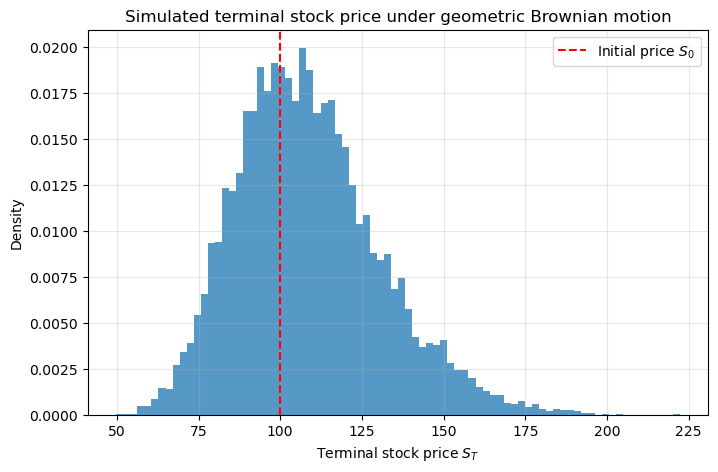

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
S0 = 100      # initial stock price
mu = 0.08     # average return
sigma = 0.2   # volatility
T = 1.0       # maturity in years
n = 10000    # number of simulations

# Simulate terminal prices under geometric Brownian motion
Z = np.random.randn(n)
ST = S0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(ST, bins=80, density=True, alpha=0.75)
plt.axvline(S0, linestyle='--', color='red', label='Initial price $S_0$')
plt.title('Simulated terminal stock price under geometric Brownian motion')
plt.xlabel('Terminal stock price $S_T$')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Interpretation

The histogram is not symmetric.
This reflects an important feature of the Black–Scholes model:

- stock prices cannot become negative,
- large positive values are possible,
- the distribution of prices is skewed to the right.

This is one reason why a lognormal model is more sensible for prices than a simple normal model.


## 7. Assumptions and consequences

Each assumption has a mathematical and financial consequence.

### Simplified summary

- **Geometric Brownian motion** gives a precise probabilistic model for the stock.
- **Constant volatility** makes the model solvable in closed form.
- **Constant interest rate** simplifies discounting.
- **No transaction costs** and **continuous trading** make dynamic hedging possible.
- **No arbitrage** connects replication and pricing.

Together, these assumptions allow the Black–Scholes model to produce the famous pricing formula.


## 8. Should we trust the model?

The right question is not:

> “Is Black–Scholes perfectly true?”

because the answer is clearly **no**.

The right question is:

> “Is Black–Scholes useful enough to help us understand and price options?”

For many purposes, the answer is **yes**.

This is why Black–Scholes is still taught everywhere:

- it is historically fundamental,
- it introduces key ideas in modern finance,
- and it remains the reference point for more advanced models.


## 9. Summary

### Main ideas to remember

- The Black–Scholes model relies on a set of strong assumptions.
- These assumptions are chosen to make option pricing mathematically manageable.
- The most important assumptions include:
  - geometric Brownian motion for the stock price,
  - constant volatility,
  - constant interest rate,
  - frictionless markets,
  - continuous trading,
  - no arbitrage.
- These assumptions are not fully realistic, but they create a powerful benchmark model.


## 10. Exercises for the student

1. Explain in your own words why continuous trading is unrealistic.
2. Why is the assumption of constant volatility convenient mathematically?
3. What is an arbitrage opportunity?
4. Why is the no-arbitrage assumption so important in option pricing?
5. Which Black–Scholes assumption do you think is the least realistic? Why?


## 11. What comes next?

The natural next step is to study the dynamics of the stock price in more detail.

In the next notebook, we can introduce:

### **Notebook 3 — Geometric Brownian Motion**

There we will explain:

- Brownian motion,
- the stochastic differential equation
  $$dS_t = \mu S_t dt + \sigma S_t dW_t,$$
- the explicit solution of this equation,
- and why the terminal stock price is lognormal.
